# The "black-swan index" — does SKEW warn you before crashes? 🪝
### CBOE's tail-risk gauge, the one the VIX supposedly can't give you, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Warns_before_crashes%3F: Busted](https://img.shields.io/badge/Warns_before_crashes%3F-Busted-8b949e?style=flat-square)

There's a number traders whisper about when they want to sound scary: the **CBOE SKEW index**. The pitch is irresistible — the VIX only measures *ordinary* fear, but SKEW reads how much people are paying for **crash insurance**: deep out-of-the-money puts that only pay off if the market falls off a cliff. So when SKEW spikes, the story goes, **the smart money is bracing for a black swan** — a warning the VIX is blind to.

A gauge that lights up *before* crashes would be priceless. This notebook asks, with 33 years of data, the only question that matters: **does a high SKEW actually precede trouble — and does it tell you anything the VIX doesn't already?**

> 📓 **Plain-language layer.** Want the regressions, the HAC *t*-stats and the block bootstrap? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from skew_index import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real SKEW/VIX/SPY cache present:", HAVE_REAL,
      "| joint days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-18', 'days': 8330, 'years': 33.4, 'skew_mean': 123.7, 'vix_mean': 19.5, 'corr': -0.19, 'reg1': (1, 8308, 0.057, 0.35, 0.427, 1.54), 'reg3': (3, 8266, 0.247, 0.49, 0.89, 1.13), 'dec1': (1, 831, 1.02, 0.97, 69, 65, 0.37, 0.619), 'dec3': (3, 827, 2.37, 2.94, 71, 72, -2.33, 0.026), 'blk1': (1, 0.05, 0.38, 0.13, 23), 'blk3': (3, -0.57, 1.13, -0.5, 13), 'tail10': (-10, 1.7, 4.4, 1.0), 'tail5': (-5, 13.7, 17.3, 0.998), 'sleeve_cagr': 9.04, 'sleeve_sharpe': 0.57, 'bh_cagr': 10.94, 'bh_sharpe': 0.65, 'pct_cash': 10, 'syn': [(0.0, 7978, 0.109, 0.42), (0.0005, 7978, -0.764, -2.85)]}


real SKEW/VIX/SPY cache present: True | joint days: 8330


## The answer first

| Question | Answer |
|---|---|
| After a high SKEW, does the market fall more often? | **No — it falls *less*.** Big drawdowns are **rarer** after a high SKEW (1.7% vs 4.4% normally). The "warning" fires before calm. |
| Does SKEW tell you anything VIX doesn't? | **No.** Once you account for the VIX, SKEW's own predictive power is statistically **zero** (and points the *wrong* way). |
| Can you trade it — de-risk when SKEW is high? | **It loses money.** Sitting out the highest-SKEW days **lowers** both your return and your risk-adjusted return. |
| Then why the scary reputation? | **It prices the crash everyone's *worried* about** — which is exactly the crash that usually doesn't come. Fear priced ≠ fear realised. |

> SKEW is a real, fascinating measurement of how much the option market *fears* a tail. It just isn't a forecast of one.

## 1 · The claim

> *"The VIX measures everyday volatility — fear of a normal-sized move. SKEW measures the price of the **tail**: how richly the market pays for deep out-of-the-money puts that only matter in a crash. So a high SKEW means insiders are loading up on crash protection — heed the warning."*

CBOE built SKEW from out-of-the-money S&P 500 option prices and scaled it so **100 = a normal, symmetric distribution**; readings of 130–145 mean the option market is pricing a *fatter left tail*. The seduction is the framing: a dedicated, real-time **black-swan detector**. We'll line it up next to the VIX and the actual future and see whether the detector detects anything.

## 2 · So what?

Two very different claims hide inside "SKEW warns you." (1) *Does a high SKEW precede weaker markets / more crashes?* And (2) *does it do so beyond what the VIX already tells you?* The second is the real test: SKEW and VIX are both squeezed from the same option prices, so if SKEW only repeats VIX's message it's noise dressed as insight. And even a genuine warning is worthless if acting on it — going to cash when SKEW is high — **costs** you return rather than saving you from drawdowns.

## 3 · How would we even know?

We take **8,330** days of daily SKEW, VIX and SPY closes (1993-01-29 → 2026-06-18, **33 years**) and do three honest things:

1. **Look forward.** After a high SKEW (top 10% of days), what did SPY do over the next **1 and 3 months** — and how often did a real **crash** (a −5% / −10% drawdown) follow, versus a normal day?
2. **Subtract the VIX.** Put SKEW *and* VIX in the same regression and ask whether SKEW adds anything once VIX is accounted for.
3. **Count the real evidence.** High-SKEW days come in a handful of *clusters*, not hundreds of independent bets — so we count the **distinct episodes** and bootstrap honestly.

## 4 · The teardown — let's actually look

**First, here's SKEW next to the VIX.** Notice they don't move together — SKEW often climbs when markets are *calm* (low VIX). That's the first clue: SKEW is pricing a fear that isn't showing up in realised volatility.

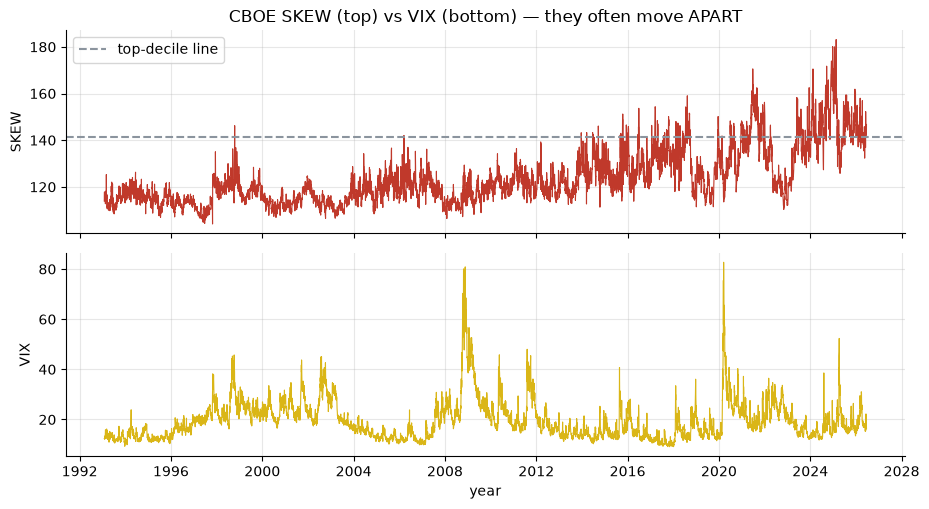

corr(SKEW, VIX) = -0.19 -> barely related


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots(2, 1, figsize=(9.4, 5.2), sharex=True)
    ax[0].plot(F.index, F['skew'], c=RED, lw=.8); ax[0].set_ylabel('SKEW')
    ax[0].axhline(F['skew'].quantile(.90), ls='--', c=GREY, label='top-decile line')
    ax[0].set_title('CBOE SKEW (top) vs VIX (bottom) — they often move APART'); ax[0].legend(loc='upper left')
    ax[1].plot(F.index, F['vix'], c=AMBER, lw=.8); ax[1].set_ylabel('VIX'); ax[1].set_xlabel('year')
    plt.tight_layout(); plt.show()
    print('corr(SKEW, VIX) =', round(F['skew'].corr(F['vix']), 2), '-> barely related')
else:
    print('no cache — see docs/results.md: corr(SKEW,VIX)=', R['corr'])

The correlation is just **-0.19** — SKEW and VIX are nearly *unrelated*, even mildly opposite. So SKEW isn't simply "VIX for the tail." Good — that means it *could*, in principle, carry its own warning. Does it?

**Does a crash follow a high SKEW?** Here's the punchline chart. After a high-SKEW day, how often does a real drawdown hit over the next month — versus a random day?

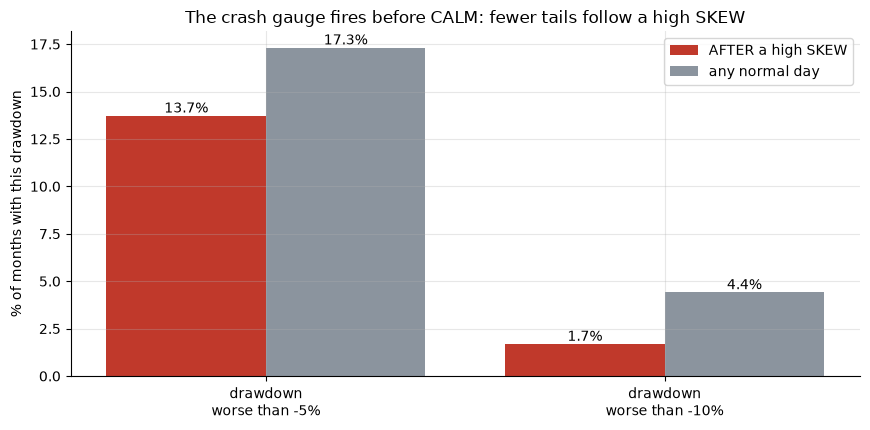

-10% drawdowns: 1.7% after high SKEW vs 4.4% normally -> LOWER, not higher


In [3]:
if HAVE_REAL:
    t10 = st.tail_warning(F, 1, dd=-0.10); t5 = st.tail_warning(F, 1, dd=-0.05)
    hi = [t5['hi_tail_rate']*100, t10['hi_tail_rate']*100]
    base = [t5['base_tail_rate']*100, t10['base_tail_rate']*100]
else:
    hi = [R['tail5'][1], R['tail10'][1]]; base = [R['tail5'][2], R['tail10'][2]]
labels = ['drawdown\nworse than -5%', 'drawdown\nworse than -10%']
x = np.arange(2)
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-.2, hi, .4, color=RED, label='AFTER a high SKEW')
ax.bar(x+.2, base, .4, color=GREY, label='any normal day')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of months with this drawdown')
ax.set_title('The crash gauge fires before CALM: fewer tails follow a high SKEW')
for i,(h,b) in enumerate(zip(hi,base)):
    ax.annotate(f'{h:.1f}%',(i-.2,h),ha='center',va='bottom')
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'-10% drawdowns: {hi[1]:.1f}% after high SKEW vs {base[1]:.1f}% normally -> LOWER, not higher')

There it is. A −10% month happens **1.7%** of the time after a high SKEW — versus **4.4%** on a normal day. The supposed crash warning is followed by **fewer** crashes. SKEW prices the tail the market is *afraid* of, and the market is usually afraid at the wrong times.

**But wait — isn't a high-SKEW day followed by weaker returns?** A little, at 3 months. The trap is that those high-SKEW days aren't hundreds of independent bets — they bunch into a *handful of episodes*. Count the real, distinct episodes and the "signal" evaporates.

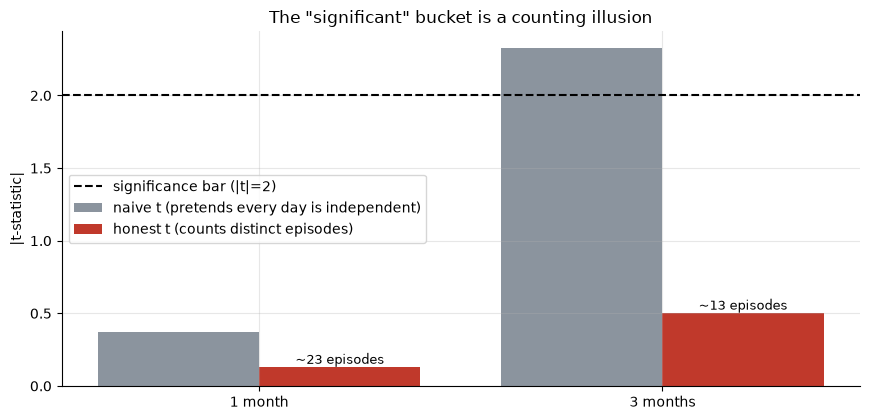

3-month: naive |t|=2.33 -> honest |t|=0.50 on only ~13 real episodes


In [4]:
if HAVE_REAL:
    b1 = st.block_bootstrap_decile(F, 1); b3 = st.block_bootstrap_decile(F, 3)
    naive_t = [st.decile_summary(F,1)['t'], st.decile_summary(F,3)['t']]
    honest_t = [b1['block_t'], b3['block_t']]; eps = [b1['n_episodes'], b3['n_episodes']]
else:
    naive_t = [R['dec1'][6], R['dec3'][6]]; honest_t = [R['blk1'][3], R['blk3'][3]]
    eps = [R['blk1'][4], R['blk3'][4]]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, [abs(t) for t in naive_t], .4, color=GREY, label='naive t (pretends every day is independent)')
ax.bar(x+.2, [abs(t) for t in honest_t], .4, color=RED, label='honest t (counts distinct episodes)')
ax.axhline(2, ls='--', c='k', label='significance bar (|t|=2)')
ax.set_xticks(x); ax.set_xticklabels(['1 month','3 months']); ax.set_ylabel('|t-statistic|')
ax.set_title('The "significant" bucket is a counting illusion'); ax.legend()
for i,(n,h,e) in enumerate(zip(naive_t,honest_t,eps)):
    ax.annotate(f'~{e} episodes',(i+.2,abs(h)),ha='center',va='bottom',fontsize=9)
plt.tight_layout(); plt.show()
print(f'3-month: naive |t|={abs(naive_t[1]):.2f} -> honest |t|={abs(honest_t[1]):.2f} on only ~{eps[1]} real episodes')

The grey bars look impressive because they treat **800+ overlapping days** as 800 separate experiments. But there are only about **13** genuinely distinct high-SKEW episodes in 33 years. Count them honestly and the *t* collapses to **-0.5** — pure noise. The "weaker 3-month returns" were a counting illusion, not a forecast.

## 5 · The verdict

- **Signal — None.** Once you control for the VIX, SKEW's own predictive power is statistically zero — and the lone "significant" bucket is a counting artifact (~13 real episodes).
- **Tradability — Mirage.** De-risking on high SKEW **loses** to buy-and-hold (**9.0%** vs **10.9%** a year), because high-SKEW days aren't followed by losses.
- **Warns before crashes? — Busted.** Big drawdowns are *rarer* after a high SKEW (**1.7%** vs **4.4%**). The black-swan gauge fires before calm.

## 6 · Could you actually trade it? — the de-risk trade

Forget significance and just *do* the obvious trade: go to cash whenever SKEW is in its top decile (the "warning"), hold SPY otherwise. If SKEW saw crashes coming, this should beat buy-and-hold by dodging the worst months. Here's what actually happens.

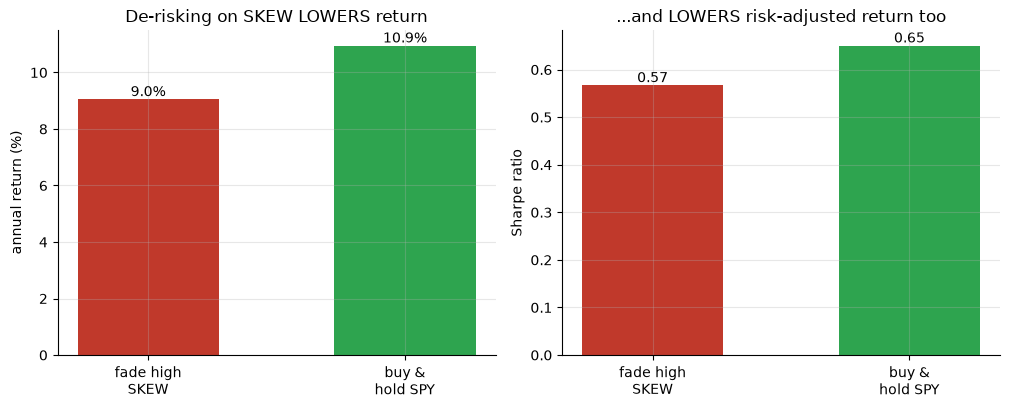

fade sleeve: 9.0% CAGR / Sharpe 0.57  vs  buy-hold 10.9% / 0.65


In [5]:
if HAVE_REAL:
    fs = st.fade_sleeve(F)
    s_cagr, s_sh, b_cagr, b_sh = fs['sleeve_cagr']*100, fs['sleeve_sharpe'], fs['bh_cagr']*100, fs['bh_sharpe']
else:
    s_cagr, s_sh, b_cagr, b_sh = R['sleeve_cagr'], R['sleeve_sharpe'], R['bh_cagr'], R['bh_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['fade high\nSKEW', 'buy &\nhold SPY'], [s_cagr, b_cagr], color=[RED, GREEN], width=.55)
a1.set_ylabel('annual return (%)'); a1.set_title('De-risking on SKEW LOWERS return')
for i,v in enumerate([s_cagr, b_cagr]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.bar(['fade high\nSKEW', 'buy &\nhold SPY'], [s_sh, b_sh], color=[RED, GREEN], width=.55)
a2.set_ylabel('Sharpe ratio'); a2.set_title('...and LOWERS risk-adjusted return too')
for i,v in enumerate([s_sh, b_sh]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'fade sleeve: {s_cagr:.1f}% CAGR / Sharpe {s_sh:.2f}  vs  buy-hold {b_cagr:.1f}% / {b_sh:.2f}')

The "warning" trade **underperforms** on both counts — **9.0%** vs **10.9%** a year, Sharpe **0.57** vs **0.65**. Every day you spent in cash "for safety" was, on average, a perfectly good day to be invested. The crash gauge cost you money by crying wolf.

## 7 · Going further 🚪

- **The honest reading of SKEW.** It's a genuine, well-built measure of how much the option market is *paying* for tail protection. That's a sentiment / risk-appetite gauge — not a forecast. The crash everyone insures against is usually the one that doesn't come.
- **Build your own test.** Swap the −10% drawdown threshold, the decile cutoff, or the horizon — the result is sticky: high SKEW does not precede more tails, and never beats VIX in the regression.
- **The deeper lesson.** *Implied* tail risk (what the market fears) and *realised* tail risk (what happens) are different objects. SKEW measures the first beautifully and the second not at all.

*Think SKEW beats VIX as a crash warning? Put both in one regression, show SKEW's coefficient clearing |t| = 2 with HAC errors, and show the de-risk trade beating buy-and-hold — then we'll talk.*